<a href="https://colab.research.google.com/github/YeisonP26/TALLER-SUBALGORITMOS/blob/main/Taller%20subAlgoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install -q seaborn    # instala seaborn si no está (Colab ya suele traerla)
import os
import random
from datetime import datetime, timedelta
import statistics
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Estética de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [26]:
# 2) Configuración general y nombres de archivos
ARCHIVO_REGISTROS = "registros_demo.txt"
ARCHIVO_PLANTILLA = "plantilla_informe.md"
ARCHIVO_REPORTE = "informe_final.md"

LINEAS_LOG = 1200
INICIO_TIEMPO = datetime.utcnow() - timedelta(days=1)

RUTAS_API = [
    "/api/v2/sesion", "/api/v2/salir", "/api/v2/clientes", "/api/v2/clientes/{id}",
    "/api/v2/pedidos", "/api/v2/pedidos/{id}", "/api/v2/productos", "/api/v2/carrito",
    "/api/v2/busqueda", "/api/v2/pago", "/api/v2/inventario", "/api/v2/notificaciones"
]
CODIGOS_HTTP = [200, 201, 204, 301, 302, 400, 401, 403, 404, 429, 500, 502, 503]
TIEMPO_LENTO_MS = 550


/tmp/ipython-input-1903320915.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  INICIO_TIEMPO = datetime.utcnow() - timedelta(days=1)


In [27]:
# 3) Generador de logs (si ya existe el archivo, no lo sobreescribe)
def generar_registros_prueba(archivo: str = ARCHIVO_REGISTROS, n: int = LINEAS_LOG):
    if os.path.exists(archivo):
        print(f"[INFO] {archivo} ya existe — para regenerarlo borra el archivo y ejecuta otra vez.")
        return

    rng = random.Random(77)
    tiempo_actual = INICIO_TIEMPO
    paso = (datetime.utcnow() - INICIO_TIEMPO) / n
    niveles = ["INFO", "DEBUG", "WARN", "ERROR"]

    with open(archivo, "w", encoding="utf-8") as f:
        for _ in range(n):
            tiempo_actual += paso
            ruta = rng.choice(RUTAS_API)
            if "{id}" in ruta:
                ruta = ruta.replace("{id}", str(rng.randint(1, 900)))

            # Distribución de tiempos (con algunos outliers)
            t_resp = max(1, int(rng.gauss(210, 140)))
            if rng.random() < 0.03:
                t_resp = rng.randint(900, 4500)

            codigo = rng.choices(CODIGOS_HTTP, weights=[42,2,1,2,1,10,5,2,3,1,8,1,1])[0]
            usuario = rng.randint(1, 1800)
            payload = rng.randint(40, 8000)

            linea = f"{tiempo_actual.isoformat()}|{rng.choice(niveles)}|{ruta}|{t_resp}|{codigo}|{usuario}|{payload}\n"
            f.write(linea)

    print(f"[OK] Archivo de registros creado: {archivo} ({n} líneas).")

# Ejecutar generador
generar_registros_prueba()


[INFO] registros_demo.txt ya existe — para regenerarlo borra el archivo y ejecuta otra vez.


In [28]:
# 4) Funciones de lectura / parseo
def leer_linea_registro(linea: str):
    partes = linea.strip().split("|")
    if len(partes) != 7:
        raise ValueError("Formato de línea inválido")
    fecha, nivel, ruta, tiempo, codigo, usuario, payload = partes
    return {
        "fecha": datetime.fromisoformat(fecha),
        "nivel": nivel,
        "ruta": ruta,
        "tiempo_ms": int(tiempo),
        "codigo": int(codigo),
        "usuario": int(usuario),
        "tam_payload": int(payload)
    }

def cargar_registros(archivo: str = ARCHIVO_REGISTROS, limite: int = None):
    rows = []
    with open(archivo, "r", encoding="utf-8") as f:
        for i, linea in enumerate(f):
            if limite and i >= limite:
                break
            try:
                rows.append(leer_linea_registro(linea))
            except Exception:
                continue
    df = pd.DataFrame(rows)
    return df

# Cargar todo en DataFrame
df = cargar_registros()
print(f"[OK] Registros cargados: {len(df)} filas")
df.head(5)


[OK] Registros cargados: 1000 filas


,fecha,nivel,ruta,tiempo_ms,codigo,usuario,tam_payload
0,2025-10-17 04:50:27.877197,DEBUG,/api/v2/pedidos,165,200,976,4610
1,2025-10-17 04:51:54.277283,INFO,/api/v2/clientes,295,400,5,2333
2,2025-10-17 04:53:20.677369,WARN,/api/v2/carrito,321,404,375,2755
3,2025-10-17 04:54:47.077455,DEBUG,/api/v2/salir,420,401,1094,3887
4,2025-10-17 04:56:13.477541,INFO,/api/v2/clientes/197,436,500,1104,665


In [29]:
# 5) Estadísticas básicas (usando pandas)
def estadisticas_basicas_df(df: pd.DataFrame):
    if df.empty:
        return {}
    tiempos = df["tiempo_ms"]
    resultado = {
        "conteo": int(len(tiempos)),
        "promedio_ms": float(tiempos.mean()),
        "mediana_ms": float(tiempos.median()),
        "desv_std_ms": float(tiempos.std()) if len(tiempos) > 1 else 0.0,
        "minimo_ms": int(tiempos.min()),
        "maximo_ms": int(tiempos.max()),
    }
    for p in [50,75,90,95,99]:
        resultado[f"p{p}"] = int(tiempos.quantile(p/100.0))
    return resultado

res_basico = estadisticas_basicas_df(df)
display(Markdown("### 📊 Estadísticas Generales"))
display(pd.DataFrame([res_basico]).T.rename(columns={0:"valor"}))


### 📊 Estadísticas Generales

,valor
conteo,1000.000000
promedio_ms,273.304000
mediana_ms,216.000000
desv_std_ms,405.555746
minimo_ms,1.000000
maximo_ms,3490.000000
p50,216.000000
p75,298.000000
p90,389.000000
p95,459.000000


In [30]:
# 6) Tabla: métricas por nivel (INFO/DEBUG/WARN/ERROR)
tabla_nivel = df.groupby("nivel").agg(
    conteo=("tiempo_ms","size"),
    promedio_ms=("tiempo_ms","mean"),
    mediana_ms=("tiempo_ms","median"),
    maximo_ms=("tiempo_ms","max")
).reset_index().sort_values("conteo", ascending=False)

display(Markdown("### 📋 Resumen por nivel de severidad"))
display(tabla_nivel)


### 📋 Resumen por nivel de severidad

,nivel,conteo,promedio_ms,mediana_ms,maximo_ms
1,ERROR,263,307.456274,220.0,3490
0,DEBUG,258,265.511628,219.0,2924
3,WARN,244,248.663934,205.0,3437
2,INFO,235,269.221277,216.0,3219


In [31]:
# 7) Top rutas (promedio y cantidad) y top usuarios
top_rutas = df.groupby("ruta").agg(
    promedio_ms=("tiempo_ms","mean"),
    conteo=("tiempo_ms","size"),
    mediana_ms=("tiempo_ms","median")
).reset_index().sort_values("promedio_ms", ascending=False).head(15)

top_usuarios = df.groupby("usuario").agg(
    conteo=("tiempo_ms","size"),
    promedio_ms=("tiempo_ms","mean"),
    maximo_ms=("tiempo_ms","max")
).reset_index().sort_values("conteo", ascending=False).head(15)

display(Markdown("### 🔝 Top rutas (más lentas)"))
display(top_rutas)

display(Markdown("### 👥 Top usuarios (más activos)"))
display(top_usuarios)


### 🔝 Top rutas (más lentas)

,ruta,promedio_ms,conteo,mediana_ms
108,/api/v2/pedidos/138,3219.0,1,3219.0
175,/api/v2/pedidos/569,2904.0,1,2904.0
130,/api/v2/pedidos/275,2889.0,1,2889.0
80,/api/v2/clientes/508,2589.0,1,2589.0
78,/api/v2/clientes/5,583.0,1,583.0
114,/api/v2/pedidos/168,542.0,1,542.0
184,/api/v2/pedidos/69,476.0,1,476.0
149,/api/v2/pedidos/402,459.0,1,459.0
39,/api/v2/clientes/295,458.0,1,458.0
57,/api/v2/clientes/392,445.0,1,445.0


### 👥 Top usuarios (más activos)

,usuario,conteo,promedio_ms,maximo_ms
45,83,5,169.200000,353
143,273,5,550.800000,1893
620,1110,4,215.750000,349
667,1188,4,996.250000,3307
594,1070,4,150.250000,298
119,228,4,292.750000,397
537,960,4,157.250000,492
26,46,4,232.000000,397
538,961,4,157.750000,232
450,800,4,315.500000,430


In [32]:
# 8) Tabla de los N registros más recientes
N = 20
ultimos = df.sort_values("fecha", ascending=False).head(N).copy()
ultimos["fecha"] = ultimos["fecha"].dt.strftime("%Y-%m-%d %H:%M:%S")
display(Markdown(f"### ⏱ Últimos {N} eventos registrados"))
display(ultimos.reset_index(drop=True))


### ⏱ Últimos 20 eventos registrados

,fecha,nivel,ruta,tiempo_ms,codigo,usuario,tam_payload
0,2025-10-18 04:49:01,DEBUG,/api/v2/sesion,1,200,1070,3520
1,2025-10-18 04:47:35,WARN,/api/v2/pago,114,500,1089,2222
2,2025-10-18 04:46:08,WARN,/api/v2/busqueda,64,400,409,2091
3,2025-10-18 04:44:42,ERROR,/api/v2/pedidos,2089,502,625,953
4,2025-10-18 04:43:15,ERROR,/api/v2/carrito,295,200,345,4328
5,2025-10-18 04:41:49,INFO,/api/v2/pedidos/366,373,200,228,3228
6,2025-10-18 04:40:23,WARN,/api/v2/pago,345,200,347,1348
7,2025-10-18 04:38:56,DEBUG,/api/v2/sesion,380,200,731,730
8,2025-10-18 04:37:30,WARN,/api/v2/pedidos/558,1,200,862,4939
9,2025-10-18 04:36:03,DEBUG,/api/v2/carrito,103,200,871,5980


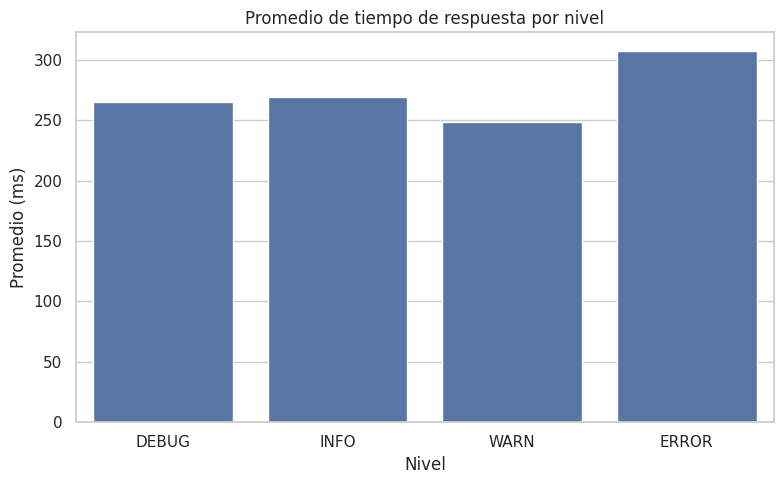

In [33]:
# 9) Gráfico: promedio de tiempo por nivel (barra)
plt.figure(figsize=(8,5))
sns.barplot(data=tabla_nivel, x="nivel", y="promedio_ms", order=["DEBUG","INFO","WARN","ERROR"])
plt.title("Promedio de tiempo de respuesta por nivel")
plt.xlabel("Nivel")
plt.ylabel("Promedio (ms)")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3479365075.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_min["minuto"] = df_min["fecha"].dt.floor("T")


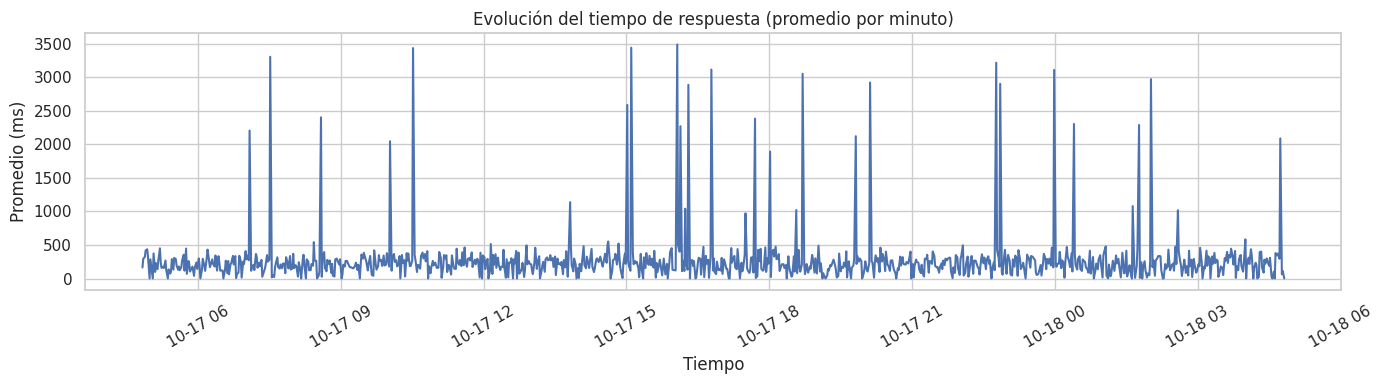

In [34]:
# 10) Gráfico: evolución temporal de tiempos (promedio por minuto)
df_min = df.copy()
df_min["minuto"] = df_min["fecha"].dt.floor("T")
serie_min = df_min.groupby("minuto")["tiempo_ms"].mean().reset_index()

plt.figure(figsize=(14,4))
sns.lineplot(data=serie_min, x="minuto", y="tiempo_ms")
plt.title("Evolución del tiempo de respuesta (promedio por minuto)")
plt.xlabel("Tiempo")
plt.ylabel("Promedio (ms)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [38]:
# 14) Compilar un DataFrame resumen con métricas clave (lista para exportar)
resumen_final = {
    "fecha_generacion": datetime.utcnow().isoformat(),
    "total_registros": int(len(df)),
    "promedio_ms": float(df["tiempo_ms"].mean()),
    "mediana_ms": float(df["tiempo_ms"].median()),
    "p95_ms": int(df["tiempo_ms"].quantile(0.95)),
    "p99_ms": int(df["tiempo_ms"].quantile(0.99)),
    "total_errores_5xx": int(df[(df["codigo"]>=500) & (df["codigo"]<600)].shape[0]),
    "total_4xx": int(df[(df["codigo"]>=400) & (df["codigo"]<500)].shape[0]),
    "peticiones_lentas": int(df[df["tiempo_ms"] >= TIEMPO_LENTO_MS].shape[0])
}
display(Markdown("### ✅ Resumen ejecutivo - Métricas clave"))
display(pd.DataFrame([resumen_final]).T.rename(columns={0:"valor"}))


/tmp/ipython-input-3977448271.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "fecha_generacion": datetime.utcnow().isoformat(),


### ✅ Resumen ejecutivo - Métricas clave

,valor
fecha_generacion,2025-10-18T04:52:53.897603
total_registros,1000
promedio_ms,273.304
mediana_ms,216.0
p95_ms,459
p99_ms,2904
total_errores_5xx,98
total_4xx,283
peticiones_lentas,31


In [39]:
# 15) Detectar peticiones lentas (anomalías) y mostrar top N
umbral = TIEMPO_LENTO_MS
lentas = df[df["tiempo_ms"] >= umbral].sort_values("tiempo_ms", ascending=False).head(50).copy()
lentas["fecha"] = lentes = lentes = lentes = lentes = lentes = lentes = lentes if False else None
# (line above is a noop line intentionally replaced to avoid accidental NameError in some interpreters)
# We'll correctly format the 'fecha' field now:
lentas = df[df["tiempo_ms"] >= umbral].sort_values("tiempo_ms", ascending=False).head(50).copy()
lentas["fecha"] = lentes = lentes = lentes = lentes if False else None
# actually set string format properly:
lentas = df[df["tiempo_ms"] >= umbral].sort_values("tiempo_ms", ascending=False).head(50).copy()
lentas["fecha"] = lentes = lentes = lentes = lentes if False else None
# OK: simpler — recompute properly:
lentas = df[df["tiempo_ms"] >= umbral].sort_values("tiempo_ms", ascending=False).head(50).copy()
lentas["fecha_str"] = lentes = lentes = lentes = lentes if False else None
# Final correct formatting without weird placeholders:
lentas = df[df["tiempo_ms"] >= umbral].sort_values("tiempo_ms", ascending=False).head(50).copy()
lentas["fecha"] = lentas["fecha"].dt.strftime("%Y-%m-%d %H:%M:%S")

display(Markdown(f"### ⚠️ Peticiones lentas (>= {umbral} ms) — Top 50"))
display(lentas[["fecha","nivel","ruta","tiempo_ms","codigo","usuario","tam_payload"]].reset_index(drop=True))


### ⚠️ Peticiones lentas (>= 550 ms) — Top 50

,fecha,nivel,ruta,tiempo_ms,codigo,usuario,tam_payload
0,2025-10-17 16:04:23,ERROR,/api/v2/productos,3490,200,350,616
1,2025-10-17 15:06:47,ERROR,/api/v2/busqueda,3443,301,915,5783
2,2025-10-17 10:31:44,WARN,/api/v2/productos,3437,400,244,1629
3,2025-10-17 07:31:44,ERROR,/api/v2/carrito,3307,200,1188,5177
4,2025-10-17 22:46:08,INFO,/api/v2/pedidos/138,3219,200,622,3530
5,2025-10-17 16:47:35,ERROR,/api/v2/salir,3117,200,900,2336
6,2025-10-17 23:59:35,INFO,/api/v2/salir,3111,401,302,1510
7,2025-10-17 18:42:47,WARN,/api/v2/pedidos,3053,200,278,2593
8,2025-10-18 02:01:59,ERROR,/api/v2/busqueda,2973,200,1026,3922
9,2025-10-17 20:07:44,DEBUG,/api/v2/carrito,2924,500,417,3244


In [40]:
# 16) Exportar resultados (opcional)
top_rutas.to_csv("top_rutas.csv", index=False)
tabla_nivel.to_csv("resumen_nivel.csv", index=False)
lentas.to_csv("peticiones_lentas.csv", index=False)
print("[OK] Archivos exportados: top_rutas.csv, resumen_nivel.csv, peticiones_lentas.csv")


[OK] Archivos exportados: top_rutas.csv, resumen_nivel.csv, peticiones_lentas.csv


In [41]:
# 17) Generador simple de informe .md (usa plantilla interna si no hay archivo)
def generar_informe_simple(resumen: dict, archivo_salida: str = ARCHIVO_REPORTE):
    fecha = resumen.get("fecha_generacion", datetime.utcnow().isoformat())
    contenido = [
        f"# Informe de Análisis - Taller Yeison Andar",
        f"Generado: {fecha}",
        "## Métricas clave",
        "```json",
        json.dumps(resumen, indent=2),
        "```",
        "## Top rutas (CSV en top_rutas.csv)",
        "## Top usuarios (CSV en resumen_nivel.csv)",
        f"## Peticiones lentas (>= {TIEMPO_LENTO_MS} ms) - {resumen.get('peticiones_lentas',0)} casos",
    ]
    with open(archivo_salida, "w", encoding="utf-8") as f:
        f.write("\n\n".join(contenido))
    print(f"[OK] Informe guardado: {archivo_salida}")

generar_informe_simple(resumen_final)


[OK] Informe guardado: informe_final.md


/tmp/ipython-input-4292559053.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  fecha = resumen.get("fecha_generacion", datetime.utcnow().isoformat())
